In [2]:
# Importa as biblioteacas para manipulação de DataFrames, carga no Bigquery e visualização exploratória de dados
import pandas as pd
from google.cloud import bigquery
import seaborn as sns

# Cria o cliente de conexão com o BigQuery.
# Este cliente será utilizado para executar queries e realizar cargas de dados
# no projeto configurado no GCP.
client = bigquery.Client(project="brazilian-ecommerce-488418")

In [3]:
# Consulta SQL para calcular o ticket médio por categoria de produto
# Regra de negócio:
# - Junta a tabela fato de pedidos com a dimensão de produtos
# - Calcula o preço médio (ticket médio) por categoria
# - Ordena do maior para o menor ticket médio
query = """
SELECT 
    product_category_name, 
    AVG(price) AS ticket_medio
FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_product` AS p
    USING(product_id)
GROUP BY product_category_name
ORDER BY ticket_medio DESC
"""

# Executa a consulta no BigQuery e converte o resultado para um DataFrame pandas
# Este DataFrame será utilizado para análises exploratórias ou visualizações
df_ticket_category = client.query(query).to_dataframe()

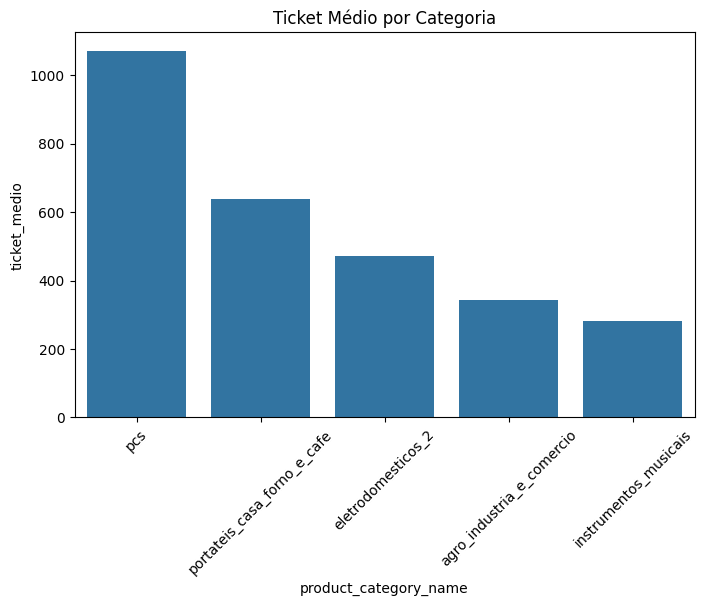

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cria um gráfico de barras para visualizar o ticket médio por categoria de produto.
# Estratégia:
# - Seleciona apenas as 5 categorias com maior ticket médio (head(5))
# - Facilita análise comparativa das categorias mais valiosas em receita média
plt.figure(figsize=(8, 5))

# Gráfico de barras: categoria no eixo X e ticket médio no eixo Y
sns.barplot(
    data=df_ticket_category.head(5),
    x='product_category_name',
    y='ticket_medio'
)

# Rotaciona os rótulos do eixo X para evitar sobreposição de textos longos
plt.xticks(rotation=45)

# Título descritivo para contextualizar a métrica exibida
plt.title('Ticket Médio por Categoria')

# Exibe o gráfico
plt.show()

In [5]:
# Consulta SQL para identificar as categorias de produtos mais compradas
# Regra de negócio:
# - Junta a tabela fato de pedidos com a dimensão de produtos
# - Conta quantos itens foram vendidos por categoria (COUNT *)
# - Ordena da categoria mais vendida para a menos vendida
query = """
    SELECT 
        p.product_category_name,
        COUNT(*) AS produtos_vendidos 
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_product` AS p
        ON f.product_id = p.product_id
    GROUP BY p.product_category_name
    ORDER BY produtos_vendidos DESC
"""

# Executa a consulta no BigQuery e converte o resultado para um DataFrame pandas
# O DataFrame resultante contém o ranking das categorias mais vendidas
df_best_selling_category = client.query(query).to_dataframe()

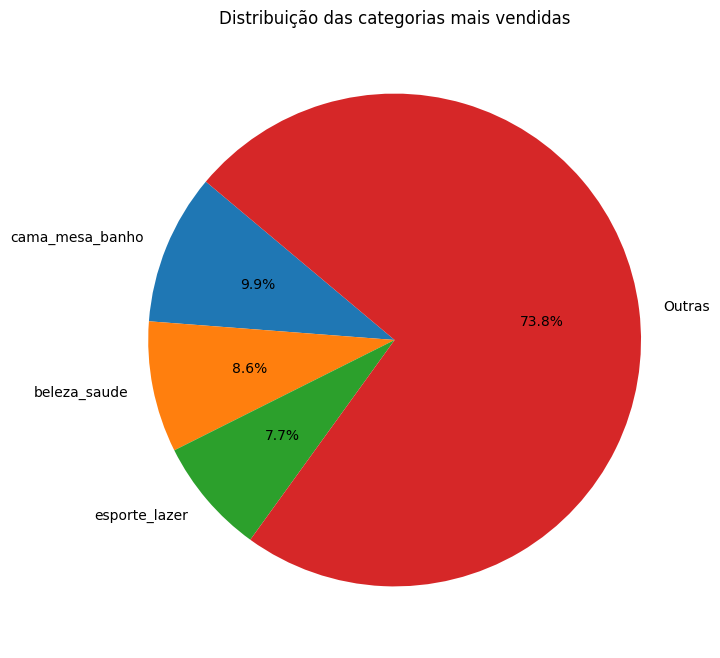

In [6]:
# Seleciona as 3 categorias mais vendidas
# Estratégia analítica: destacar as categorias principais para melhor visualização
top3 = df_best_selling_category.head(3)

# Separa as demais categorias (menos relevantes individualmente)
rest = df_best_selling_category[3:]

# Cria uma nova linha agregando todas as categorias restantes como "Outras"
# Isso evita poluição visual no gráfico de pizza e melhora a interpretação
df_others = pd.DataFrame([{
    'product_category_name': 'Outras',
    'produtos_vendidos': rest['produtos_vendidos'].sum()
}])

# Combina as top 3 categorias com a categoria agregada "Outras"
df_pie = pd.concat([top3, df_others], ignore_index=True)

# Cria gráfico de pizza para visualizar a distribuição das categorias mais vendidas
plt.figure(figsize=(8, 8))
plt.pie(
    df_pie['produtos_vendidos'],
    labels=df_pie['product_category_name'],
    autopct='%1.1f%%',  # Exibe porcentagem com uma casa decimal
    startangle=140      # Ajusta rotação inicial para melhor estética
)

# Título explicativo do objetivo analítico do gráfico
plt.title('Distribuição das categorias mais vendidas')

# Exibe o gráfico final
plt.show()

In [7]:
# Consulta SQL para calcular o total de vendas por cidade dos vendedores
# Regra de negócio:
# - Junta a tabela fato de pedidos com a dimensão de vendedores
# - Soma o valor das vendas (price) por cidade do seller
# - Permite identificar quais cidades concentram maior volume financeiro de vendas
query = """
    SELECT 
        s.seller_city,
        SUM(f.price) AS vendas_totais
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_seller` AS s
        ON f.seller_id = s.seller_id
    GROUP BY s.seller_city
    ORDER BY vendas_totais DESC
"""

# Executa a consulta no BigQuery e converte o resultado para DataFrame pandas
# O resultado representa o faturamento total por cidade dos vendedores
df_sales_per_city = client.query(query).to_dataframe()

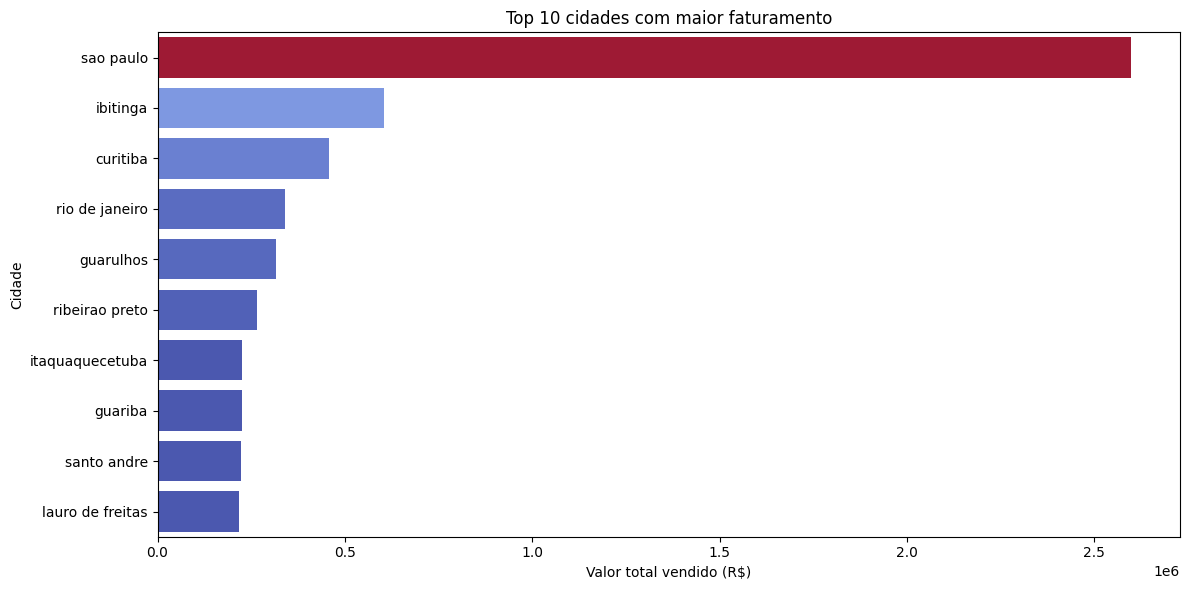

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cria a figura do gráfico com tamanho 12x6
plt.figure(figsize=(12,6))

# Cria um gráfico de barras com seaborn
sns.barplot(
    data=df_sales_per_city.head(10),  # usa apenas as 10 cidades com maior valor de vendas
    x='vendas_totais',               # eixo X → valor total vendido por cidade
    y='seller_city',                 # eixo Y → nome da cidade do vendedor
    hue='vendas_totais',             # define gradiente de cores com base nos valores
    palette='coolwarm',              # paleta de cores
    dodge=False                      # impede barras lado a lado
)

# Remove a legenda desnecessária (já que cada barra é individual)
plt.legend([],[], frameon=False)

# Define o título do gráfico
plt.title('Top 10 cidades com maior faturamento')

# Define o rótulo do eixo X (valor total vendido em reais)
plt.xlabel('Valor total vendido (R$)')

# Define o rótulo do eixo Y (cidade do vendedor)
plt.ylabel('Cidade')

# Ajusta automaticamente os espaçamentos para não cortar textos
plt.tight_layout()

# Exibe o gráfico na tela
plt.show()

In [9]:
# Tendência de vendas por período (mês)

# Query SQL para obter o total de vendas por mês
query = """
    SELECT 
        t.month,                  
        SUM(f.price) AS vendas_mes 
    FROM `brazilian-ecommerce-488418.ecommerce_dw.fact_order` AS f
    JOIN `brazilian-ecommerce-488418.ecommerce_dw.dim_time` AS t
        ON f.time_id = t.time_id   
    GROUP BY t.month               
    ORDER BY vendas_mes DESC       
""" 

# Executa a query no BigQuery e converte o resultado para DataFrame pandas
df_month_sales = client.query(query).to_dataframe()

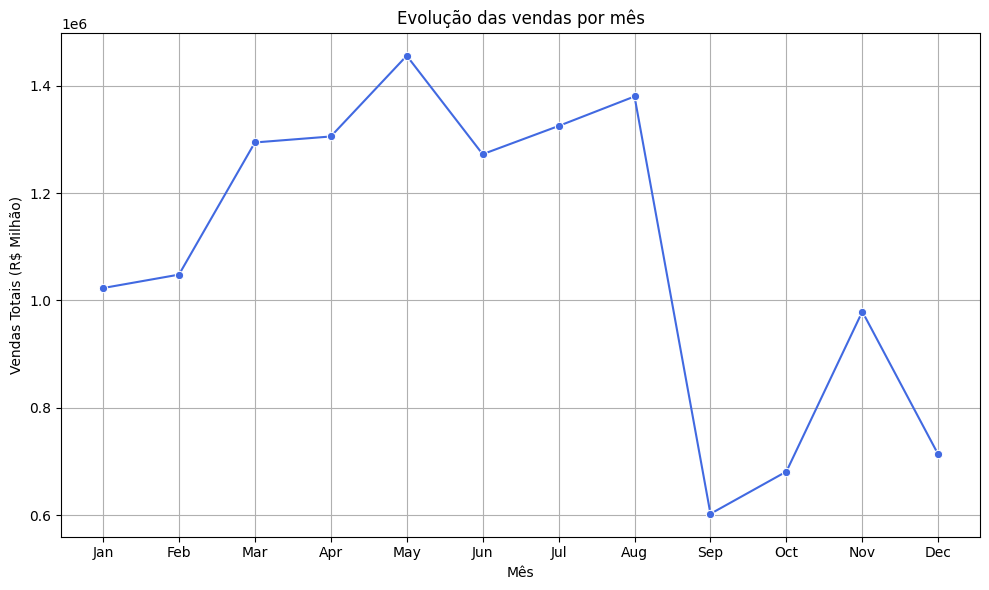

In [10]:
# Importa a biblioteca calendar para converter número do mês em nome abreviado
import calendar

# Define o tamanho da figura do gráfico (largura x altura)
plt.figure(figsize=(10,6))

# Cria um gráfico de linha para mostrar a evolução das vendas por mês
sns.lineplot(
    data=df_month_sales,   # DataFrame com os dados agregados por mês
    x='month',             # eixo X representa o mês (1 a 12)
    y='vendas_mes',        # eixo Y representa o total de vendas no mês
    marker='o',            # adiciona um ponto em cada mês para destacar os valores
    color='royalblue'      # define a cor da linha
)

# Cria lista com abreviações dos meses (Jan, Feb, Mar, ...)
meses = [calendar.month_abbr[i] for i in range(1, 13)]

# Define os rótulos do eixo X com os nomes dos meses em vez de números
plt.xticks(
    ticks=range(1,13),  # posições dos meses de 1 a 12
    labels=meses        # nomes abreviados dos meses
)

# Título do gráfico
plt.title('Evolução das vendas por mês')

# Rótulo do eixo X
plt.xlabel('Mês')

# Rótulo do eixo Y
plt.ylabel('Vendas Totais (R$ Milhão)')

# Adiciona grade para facilitar visualização dos valores
plt.grid(True)

# Ajusta automaticamente os espaçamentos do layout
plt.tight_layout()

# Exibe o gráfico
plt.show()